# Multimodal Contradiction Project

Authors: Saj Patel and Prathamesh Swar.

This notebook implements the project pipeline in short sections.
The helper modules under `src/vl_contradiction` hold the heavier logic so each cell stays readable.

## 1. Notebook Bootstrap

Use this section to resolve the project root, optionally install dependencies, and expose the package for imports.
When running in Colab, the notebook clones the repo into `/content/project` and keeps COCO data plus all derived artifacts on the local Colab runtime filesystem under the configured `artifacts/` directories.

In [2]:
from pathlib import Path
import shutil
import subprocess
import sys

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    GITHUB_OWNER = "sajpatel15"
    GITHUB_REPO = "comp_646_project"
    PROJECT_ROOT = Path("/content/project")
    repo_url = f"https://github.com/{GITHUB_OWNER}/{GITHUB_REPO}.git"

    if PROJECT_ROOT.exists() and not (PROJECT_ROOT / "pyproject.toml").exists():
        shutil.rmtree(PROJECT_ROOT)

    if (PROJECT_ROOT / ".git").exists():
        subprocess.run(["git", "-C", str(PROJECT_ROOT), "remote", "set-url", "origin", repo_url], check=True)
        pull_result = subprocess.run(
            [
                "git",
                "-C",
                str(PROJECT_ROOT),
                "pull",
                "--ff-only",
            ],
            capture_output=True,
            text=True,
        )
        print(pull_result.stdout)
        if pull_result.returncode != 0:
            print(pull_result.stderr)
            raise RuntimeError("Git pull failed. Remove /content/project or fix the repo state.")

    if not (PROJECT_ROOT / "pyproject.toml").exists():
        clone_result = subprocess.run(
            [
                "git",
                "clone",
                repo_url,
                str(PROJECT_ROOT),
            ],
            capture_output=True,
            text=True,
        )
        print(clone_result.stdout)
        if clone_result.returncode != 0:
            print(clone_result.stderr)
            raise RuntimeError("Git clone failed. Confirm the public repo URL is reachable.")
else:
    PROJECT_ROOT = Path.cwd().resolve()
    if PROJECT_ROOT.name == "notebooks":
        PROJECT_ROOT = PROJECT_ROOT.parent
    if not (PROJECT_ROOT / "pyproject.toml").exists():
        raise FileNotFoundError(f"Could not locate project root from {PROJECT_ROOT}")

# Colab runs include the optional Qwen stack so RUN_QWEN can execute without a second install step.
editable_target = f"{PROJECT_ROOT}[qwen]" if IN_COLAB else str(PROJECT_ROOT)
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e", editable_target], check=True)

src_path = PROJECT_ROOT / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

print(f"Project root: {PROJECT_ROOT}")
print(f"Project files found: {(PROJECT_ROOT / 'pyproject.toml').exists()}")
print(f"Editable install target: {editable_target}")


Already up to date.

Project root: /content/project
Project files found: True
Editable install target: /content/project[qwen]


In [3]:
print(f"Project root exists: {PROJECT_ROOT.exists()}")
print(f"Package root exists: {(PROJECT_ROOT / 'src' / 'vl_contradiction').exists()}")
sorted(path.name for path in (PROJECT_ROOT / 'src').iterdir())

Project root exists: True
Package root exists: True


['multimodal_contradiction_project.egg-info', 'vl_contradiction']

In [4]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from vl_contradiction.benchmark import build_benchmark, sample_comparison_subset
from vl_contradiction.coco import ensure_coco_dataset, load_coco_caption_context
from vl_contradiction.config import load_config
from vl_contradiction.labels import CLASS_ORDER, LABEL_TO_INDEX
from vl_contradiction.metrics import (
    bootstrap_macro_f1_ci,
    compute_classification_metrics,
    expected_calibration_error,
    fit_temperature,
    per_edit_family_metrics,
)
from vl_contradiction.reporting import (
    save_comparison_tables,
    select_matched_qualitative_samples,
    slice_prediction_frame,
    standardize_prediction_frame,
)
from vl_contradiction.runtime import detect_runtime, ensure_directories, print_runtime_summary, scope_runtime, set_global_seed


In [5]:
from vl_contradiction.clip_baselines import (
    ClipSplitOutputs,
    extract_clip_split_outputs,
    fit_binary_similarity_threshold,
    load_clip_bundle,
    predict_with_threshold,
)
from vl_contradiction.models import CrossAttentionFusionClassifier, LinearProbe
from vl_contradiction.plotting import (
    build_qualitative_panel_figure,
    resolve_figure_output,
    save_benchmark_spot_checks,
    save_confusion_matrix,
    save_grouped_comparison_chart,
    save_per_family_accuracy_heatmap,
    save_qualitative_panel,
    save_reliability_diagram,
    save_score_histogram,
    save_threshold_sweep,
    save_training_curves,
)
from vl_contradiction.qwen import load_qwen_bundle, run_qwen_inference
from vl_contradiction.training import FeatureDataset, TokenDataset, get_stage_trials, run_training_sweep


In [6]:
from IPython.display import display
from PIL import Image


def show_saved_figure(path, title=None, figsize=(8, 5)):
    path = Path(path)
    if not path.exists():
        print(f"Missing figure: {path}")
        return
    fig, ax = plt.subplots(figsize=figsize)
    with Image.open(path) as image:
        ax.imshow(image)
    ax.axis('off')
    if title:
        ax.set_title(title)
        fig.subplots_adjust(left=0.01, right=0.99, bottom=0.01, top=0.93)
    else:
        fig.subplots_adjust(left=0.01, right=0.99, bottom=0.01, top=0.99)
    plt.show()
    plt.close(fig)


def show_prediction_examples(frame, title, n=4, seed=42):
    if frame.empty:
        print(f"No rows available for {title}")
        return

    sample = frame.sample(min(n, len(frame)), random_state=seed).reset_index(drop=True)
    fig = build_qualitative_panel_figure(sample, title, max_rows=len(sample))
    plt.show()
    plt.close(fig)


def export_model_predictions(frame, model_name, comparison_sample_ids, output_path, stage):
    full_export = standardize_prediction_frame(
        frame,
        model=model_name,
        stage=stage,
        eval_scope='test',
    )
    comparison_export = slice_prediction_frame(full_export, comparison_sample_ids).copy()
    comparison_export['eval_scope'] = 'comparison_subset'
    combined_export = pd.concat([full_export, comparison_export], ignore_index=True)
    combined_export.to_csv(output_path, index=False)
    return full_export, comparison_export, combined_export


## 2. Configuration and Runtime

Load the shared config, resolve runtime paths, and create the artifact directories up front.

In [7]:
config = load_config(PROJECT_ROOT / "configs" / "default.yaml")
runtime = detect_runtime(PROJECT_ROOT, config)
runtime_paths = [
    runtime.cache_root,
    runtime.dataset_root,
    runtime.benchmark_root,
    runtime.checkpoint_root,
    runtime.log_root,
    runtime.metrics_root,
    runtime.figure_root,
    runtime.qwen_root,
]
if runtime.performance.qwen_cache_mode == "scratch_then_sync":
    runtime_paths.append(runtime.qwen_scratch_root)
ensure_directories(runtime_paths)
set_global_seed(config.runtime.seed)
print_runtime_summary(runtime)
print(f"Image splits for this run: {config.data.image_splits}")


Runtime summary
  project_root: /content/project
  cache_root:   /content/project
  dataset_root: /content/project/artifacts/datasets/coco2017
  benchmark:    /content/project/artifacts/benchmark
  checkpoints:  /content/project/artifacts/checkpoints
  metrics:      /content/project/artifacts/metrics
  figures:      /content/project/artifacts/figures
  colab:        True
  device:       cuda
  perf profile: t4
  clip dtype:   fp16
  qwen dtype:   fp16
  train amp:    fp16
  qwen batch:   4
  qwen cache:   direct
  gpu:          Tesla T4 (14.6 GB)
Image splits for this run: ['val']


In [8]:
RUN_RAW_CLIP = True
RUN_LINEAR_PROBE = True
RUN_CROSS_ATTENTION = True
RUN_QWEN = True
QWEN_BATCH_SIZE_OVERRIDE = 28  # final-run Qwen batch size for Colab GPU execution
CURRENT_STAGE = "final"

runtime = scope_runtime(runtime, CURRENT_STAGE)
stage_paths = [
    runtime.benchmark_root,
    runtime.checkpoint_root,
    runtime.log_root,
    runtime.metrics_root,
    runtime.figure_root,
    runtime.qwen_root,
]
if runtime.performance.qwen_cache_mode == "scratch_then_sync":
    stage_paths.append(runtime.qwen_scratch_root)
ensure_directories(stage_paths)
family_limit = getattr(config.data, f"{CURRENT_STAGE}_families")
print(f"Stage: {CURRENT_STAGE} | families: {family_limit}")
print_runtime_summary(runtime)


Stage: final | families: 8000
Runtime summary
  project_root: /content/project
  cache_root:   /content/project
  dataset_root: /content/project/artifacts/datasets/coco2017
  benchmark:    /content/project/artifacts/benchmark/final
  checkpoints:  /content/project/artifacts/checkpoints/final
  metrics:      /content/project/artifacts/metrics/final
  figures:      /content/project/artifacts/figures/final
  colab:        True
  device:       cuda
  perf profile: t4
  clip dtype:   fp16
  qwen dtype:   fp16
  train amp:    fp16
  qwen batch:   4
  qwen cache:   direct
  gpu:          Tesla T4 (14.6 GB)


## 2A. Live Monitoring

Use this optional cell to open TensorBoard inline while training logs are being written.

In [9]:
ip = get_ipython()
if ip is None:
    print(f"TensorBoard logs will be written to: {runtime.log_root}")
else:
    try:
        ip.run_line_magic("load_ext", "tensorboard")
    except Exception:
        pass
    print(f"TensorBoard logdir: {runtime.log_root}")
    try:
        ip.run_line_magic("tensorboard", f"--logdir {runtime.log_root}")
    except Exception as exc:
        print(f"TensorBoard launch note: {exc}")

TensorBoard logdir: /content/project/artifacts/logs/final


<IPython.core.display.Javascript object>

## 3. COCO Download and Validation

This section checks the local Colab dataset cache first and downloads only the requested COCO image splits plus annotations when needed.

In [10]:
coco_paths = ensure_coco_dataset(runtime.dataset_root, download=True, image_splits=config.data.image_splits)
print(coco_paths)

Preparing COCO dataset under /content/project/artifacts/datasets/coco2017


Extracting val_images.zip


Extracting annotations.zip
CocoPaths(dataset_root=PosixPath('/content/project/artifacts/datasets/coco2017'), train_images_dir=PosixPath('/content/project/artifacts/datasets/coco2017/train2017'), val_images_dir=PosixPath('/content/project/artifacts/datasets/coco2017/val2017'), annotations_dir=PosixPath('/content/project/artifacts/datasets/coco2017/annotations'), instances_train=PosixPath('/content/project/artifacts/datasets/coco2017/annotations/instances_train2017.json'), instances_val=PosixPath('/content/project/artifacts/datasets/coco2017/annotations/instances_val2017.json'), captions_train=PosixPath('/content/project/artifacts/datasets/coco2017/annotations/captions_train2017.json'), captions_val=PosixPath('/content/project/artifacts/datasets/coco2017/annotations/captions_val2017.json'))


In [11]:
coco_frame = load_coco_caption_context(coco_paths, splits=config.data.image_splits)
print(coco_frame.shape)
coco_frame.head(2)

Loading COCO metadata for split=val
(25014, 13)


,family_id,caption_id,image_id,caption,split_source,file_name,file_path,objects,object_counts,height,width,category_vocab,caption_length
0,val-38,38,179765,A black Honda motorcycle parked in front of a ...,val,000000179765.jpg,/content/project/artifacts/datasets/coco2017/v...,[motorcycle],{'motorcycle': 1},480,640,"[airplane, apple, backpack, banana, baseball b...",10
1,val-182,182,179765,A Honda motorcycle parked in a grass driveway,val,000000179765.jpg,/content/project/artifacts/datasets/coco2017/v...,[motorcycle],{'motorcycle': 1},480,640,"[airplane, apple, backpack, banana, baseball b...",8


## 4. Benchmark Construction

Build the benchmark from deterministic edits, then save the records and the family split manifest.

Building benchmark from 8000 source caption families
Built 4552 benchmark rows across 2276 families
Family coverage summary
           label              edit_family  candidate_count  selected_count  \
0  contradiction     contradiction_action             1282             683   
1  contradiction  contradiction_attribute              386             384   
2  contradiction      contradiction_count              873             642   
3  contradiction     contradiction_object              678             567   
4     entailment       entailment_synonym             2276            2276   

   target_count  meets_target  
0          2000         False  
1          2000         False  
2          2000         False  
3          2000         False  
4          8000         False  
Saved benchmark to /content/project/artifacts/benchmark/final/benchmark_final.csv
Saved family manifest to /content/project/artifacts/benchmark/final/family_manifest_final.csv
Saved coverage summary to /content/proj

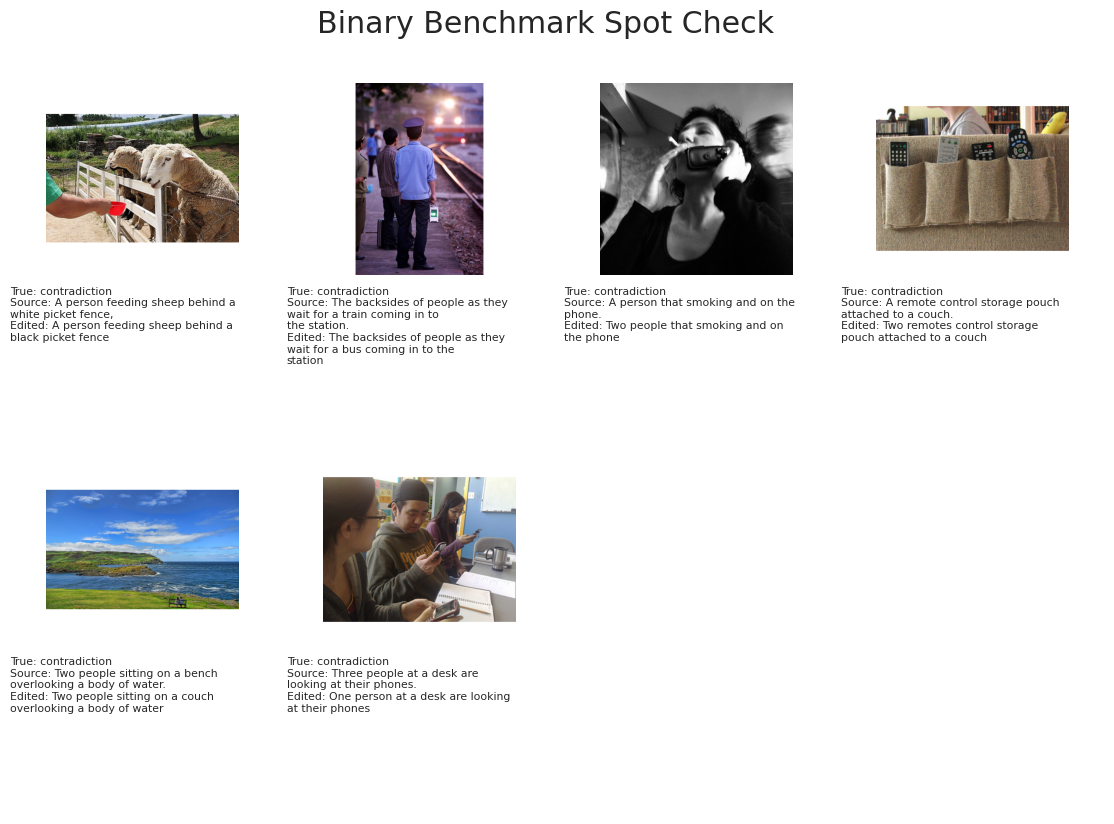

Saved benchmark spot checks to /content/project/artifacts/figures/final/benchmark
Saved benchmark spot check manifest to /content/project/artifacts/figures/final/benchmark/benchmark_spot_checks_final.csv


,sample_id,family_id,image_id,source_caption,edited_caption,label,edit_family,edit_rule,audit_status,file_path,objects,object_counts,split
0,val-199335::entailment,val-199335,458410,A living room with an old fashioned TV and a c...,A living room with an old fashioned TELEVISION...,entailment,entailment_synonym,synonym:tv->television,pending,/content/project/artifacts/datasets/coco2017/v...,"[book, couch, dining table, tv, wine glass]","{'tv': 1, 'couch': 1, 'wine glass': 7, 'book':...",train
1,val-199335::contradiction,val-199335,458410,A living room with an old fashioned TV and a c...,A living room with an old fashioned TV and a b...,contradiction,contradiction_object,object:couch->bench,pending,/content/project/artifacts/datasets/coco2017/v...,"[book, couch, dining table, tv, wine glass]","{'tv': 1, 'couch': 1, 'wine glass': 7, 'book':...",train
2,val-438468::entailment,val-438468,267537,People sitting under umbrellas on bleachers wi...,Individuals sitting under umbrellas on bleache...,entailment,entailment_synonym,synonym:people->individuals,pending,/content/project/artifacts/datasets/coco2017/v...,"[bench, person, tie, umbrella]","{'umbrella': 2, 'person': 10, 'bench': 12, 'ti...",train


In [12]:
benchmark_result = build_benchmark(
    coco_frame=coco_frame,
    family_limit=family_limit,
    split_ratio=config.data.split_ratio,
    seed=config.runtime.split_seed,
)
benchmark_frame = benchmark_result.records.copy()
family_manifest = benchmark_result.family_manifest.copy()
coverage_summary = benchmark_result.coverage_summary.copy()

benchmark_path = runtime.benchmark_root / f"benchmark_{CURRENT_STAGE}.csv"
manifest_path = runtime.benchmark_root / f"family_manifest_{CURRENT_STAGE}.csv"
coverage_path = runtime.benchmark_root / f"benchmark_coverage_{CURRENT_STAGE}.csv"
benchmark_frame.to_csv(benchmark_path, index=False)
family_manifest.to_csv(manifest_path, index=False)
coverage_summary.to_csv(coverage_path, index=False)

if benchmark_frame.empty:
    raise RuntimeError("Benchmark generation returned zero rows. Check the COCO split and edit rules.")

coverage_minimum = config.data.audit_samples_per_family
coverage_shortfalls = coverage_summary.loc[coverage_summary["selected_count"] < coverage_minimum].copy()

print(f"Saved benchmark to {benchmark_path}")
print(f"Saved family manifest to {manifest_path}")
print(f"Saved coverage summary to {coverage_path}")
print(coverage_summary)
if not coverage_shortfalls.empty:
    print(f"Coverage below the minimum family count ({coverage_minimum}) for:")
    print(coverage_shortfalls[["edit_family", "selected_count", "target_count"]])
print(benchmark_frame[["label", "edit_family", "split"]].value_counts().head(12))
show_prediction_examples(benchmark_frame, "Binary Benchmark Spot Check", n=6, seed=config.runtime.seed)
benchmark_spot_check_manifest = runtime.figure_root / 'benchmark' / f"benchmark_spot_checks_{CURRENT_STAGE}.csv"
save_benchmark_spot_checks(
    benchmark_frame,
    runtime.figure_root / 'benchmark',
    sample_count=5,
    seed=config.runtime.seed,
    manifest_name=benchmark_spot_check_manifest.name,
)
print(f"Saved benchmark spot checks to {runtime.figure_root / 'benchmark'}")
print(f"Saved benchmark spot check manifest to {benchmark_spot_check_manifest}")
benchmark_frame.head(3)


## 5. Split Views

Keep split-specific frames small and explicit so downstream sections stay easy to read.

In [13]:
split_frames = {
    split: benchmark_frame.loc[benchmark_frame['split'] == split].reset_index(drop=True)
    for split in ['train', 'val', 'test']
}
for split, frame in split_frames.items():
    print(f"{split}: {frame.shape}")

comparison_subset = sample_comparison_subset(
    split_frames['test'],
    subset_size=config.data.qwen_subset_size,
    seed=config.runtime.split_seed,
)
comparison_subset_path = runtime.metrics_root / f"comparison_subset_{CURRENT_STAGE}.csv"
comparison_subset.to_csv(comparison_subset_path, index=False)
comparison_sample_ids = comparison_subset['sample_id'].tolist()
print(
    f"Saved comparison subset to {comparison_subset_path} "
    f"({len(comparison_subset)} of {len(split_frames['test'])} test rows)"
)
comparison_subset[['label', 'edit_family']].value_counts().head(12)


train: (3186, 13)
val: (684, 13)
test: (682, 13)
Saved comparison subset to /content/project/artifacts/metrics/final/comparison_subset_final.csv (682 of 682 test rows)


label          edit_family            
entailment     entailment_synonym         341
contradiction  contradiction_count        118
               contradiction_action        98
               contradiction_attribute     64
               contradiction_object        61
Name: count, dtype: int64

## 6. Raw CLIP Baseline

Fit CLIP thresholds on validation only, then evaluate on test.

In [14]:
clip_bundle = load_clip_bundle(
    config.model.clip_name,
    runtime.device,
    precision=runtime.performance.clip_precision,
    num_workers=runtime.performance.clip_num_workers,
    persistent_workers=runtime.performance.persistent_workers,
    prefetch_factor=runtime.performance.prefetch_factor,
)
requested_clip_batch_sizes = []
if RUN_RAW_CLIP:
    requested_clip_batch_sizes.append(config.training.clip_batch_size)
if RUN_LINEAR_PROBE:
    requested_clip_batch_sizes.append(config.training.joint_feature_batch_size)
if RUN_CROSS_ATTENTION:
    requested_clip_batch_sizes.append(config.training.token_feature_batch_size)
clip_shared_batch_size = min(requested_clip_batch_sizes) if requested_clip_batch_sizes else config.training.clip_batch_size
clip_split_outputs: dict[str, ClipSplitOutputs] = {}
if RUN_RAW_CLIP or RUN_LINEAR_PROBE or RUN_CROSS_ATTENTION:
    for split in ['train', 'val', 'test']:
        clip_split_outputs[split] = extract_clip_split_outputs(
            split_frames[split],
            clip_bundle,
            batch_size=clip_shared_batch_size,
        )
        print(
            f"Prepared shared CLIP outputs for {split}: "
            f"scores={tuple(clip_split_outputs[split].raw_scores.shape)} "
            f"joint={tuple(clip_split_outputs[split].joint_features.shape)} "
            f"image_tokens={tuple(clip_split_outputs[split].image_tokens.shape)} "
            f"text_tokens={tuple(clip_split_outputs[split].text_tokens.shape)}"
        )


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


...

Prepared shared CLIP outputs for train: scores=(3186,) joint=(3186, 1025) image_tokens=(3186, 50, 768) text_tokens=(3186, 77, 512)


CLIP features:   0%|          | 0/86 [00:00<?, ?it/s]

Prepared shared CLIP outputs for val: scores=(684,) joint=(684, 1025) image_tokens=(684, 50, 768) text_tokens=(684, 77, 512)


CLIP features:   0%|          | 0/86 [00:00<?, ?it/s]

Prepared shared CLIP outputs for test: scores=(682,) joint=(682, 1025) image_tokens=(682, 50, 768) text_tokens=(682, 77, 512)


In [15]:
if RUN_RAW_CLIP:
    val_outputs = clip_split_outputs['val']
    test_outputs = clip_split_outputs['test']
    val_scores = pd.DataFrame(
        {
            'sample_id': val_outputs.sample_ids,
            'label': val_outputs.labels,
            'raw_score': val_outputs.raw_scores.numpy().astype(float),
        }
    )
    threshold_config, threshold_search = fit_binary_similarity_threshold(
        labels=val_scores['label'].tolist(),
        scores=val_scores['raw_score'].to_numpy(),
        grid_size=config.evaluation.threshold_grid_size,
    )
    test_scores = pd.DataFrame(
        {
            'sample_id': test_outputs.sample_ids,
            'label': test_outputs.labels,
            'raw_score': test_outputs.raw_scores.numpy().astype(float),
        }
    )
    test_predictions = predict_with_threshold(
        test_scores['raw_score'].to_numpy(),
        tau=threshold_config['tau'],
    )
    y_true = test_scores['label'].map(LABEL_TO_INDEX).to_numpy()
    clip_metrics = compute_classification_metrics(y_true, test_predictions)
    clip_ci = bootstrap_macro_f1_ci(y_true, test_predictions, samples=config.evaluation.bootstrap_samples, seed=config.runtime.seed)
    print("Raw CLIP metrics", clip_metrics)
    print("Raw CLIP macro-F1 95% CI", clip_ci)


Raw CLIP metrics {'accuracy': 0.6290322580645161, 'macro_f1': 0.6285331077139025, 'precision_contradiction': 0.6202185792349727, 'precision_entailment': 0.6392405063291139, 'recall_contradiction': 0.6656891495601173, 'recall_entailment': 0.592375366568915, 'confusion_matrix': [[227, 114], [139, 202]]}
Raw CLIP macro-F1 95% CI (0.593233037846394, 0.6644562068679424)


Saved raw CLIP metrics to /content/project/artifacts/metrics/final/raw_clip_metrics_final.json
Saved raw CLIP per-family metrics to /content/project/artifacts/metrics/final/raw_clip_per_family_final.csv
Saved raw CLIP prediction export to /content/project/artifacts/metrics/final/raw_clip_predictions_final.csv
Threshold: tau=0.2972


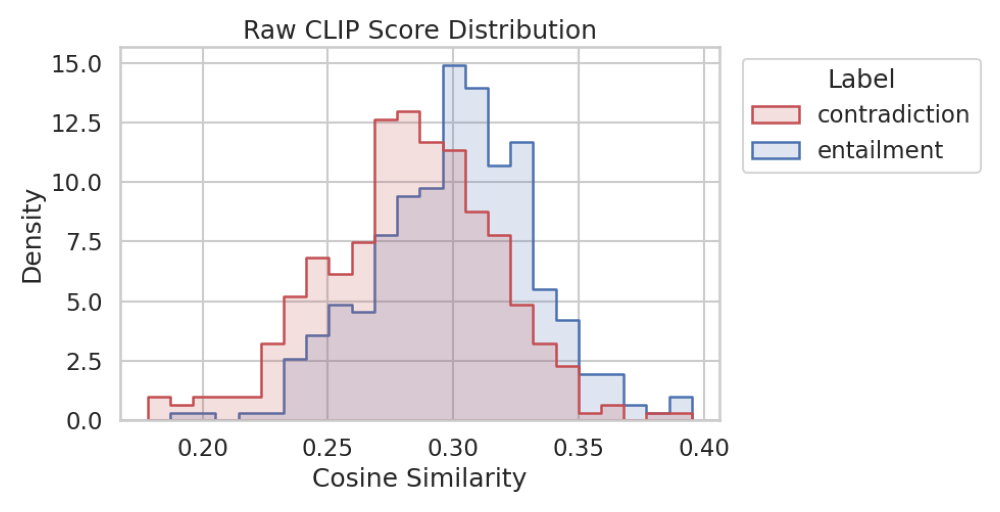

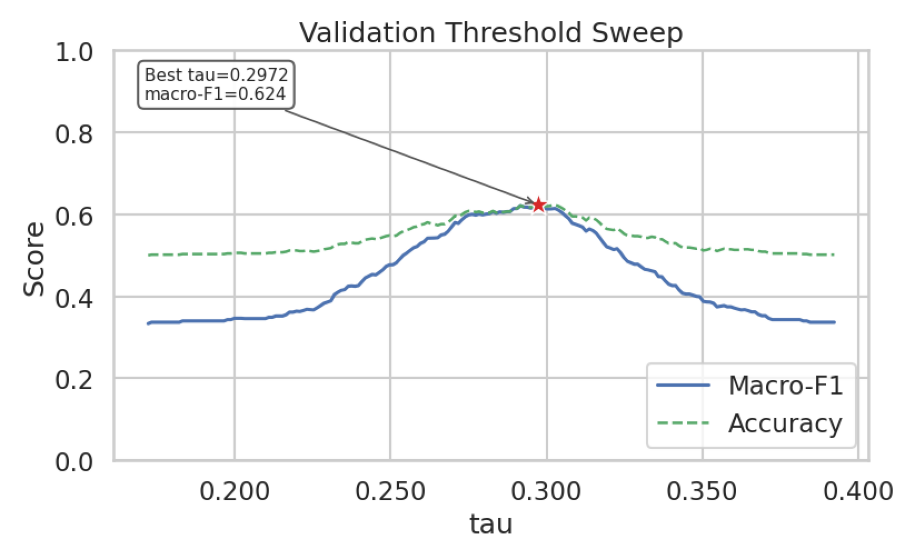

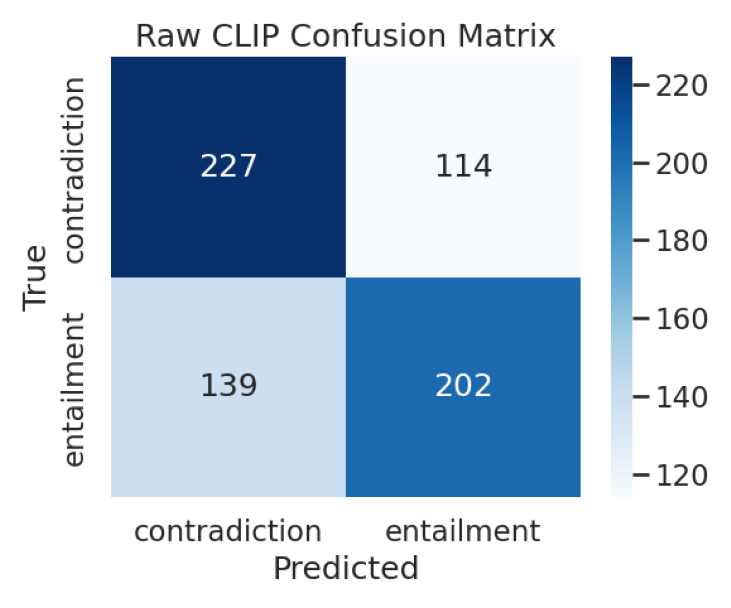

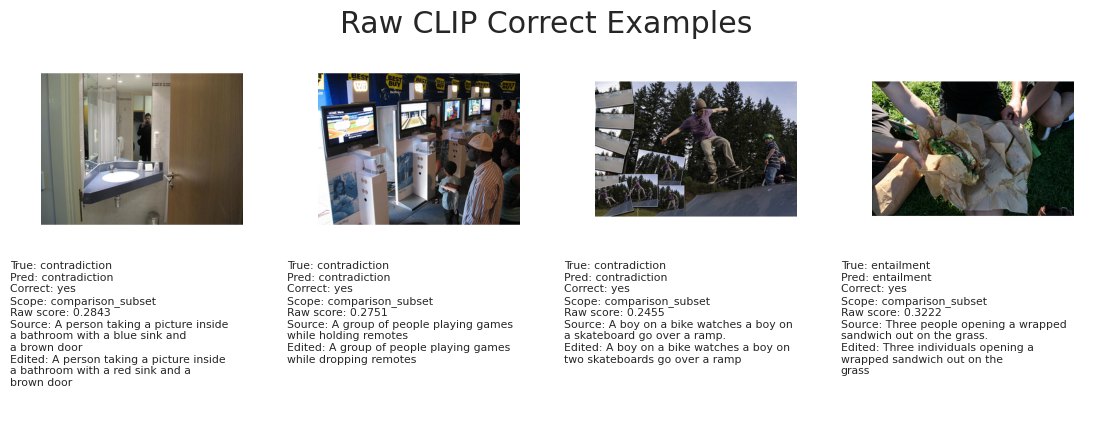

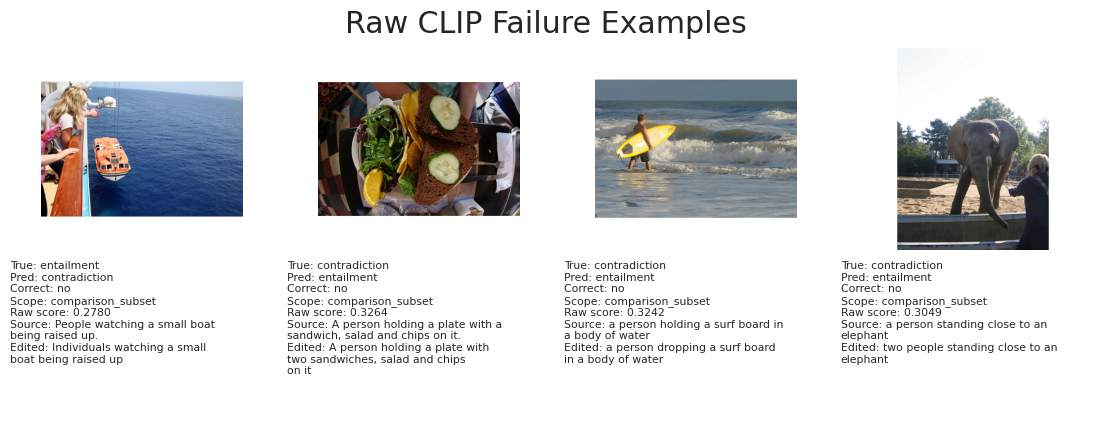

In [16]:
if RUN_RAW_CLIP:
    raw_clip_view = split_frames['test'].merge(
        test_scores[['sample_id', 'raw_score']],
        on='sample_id',
        how='left',
    ).copy()
    raw_clip_view['pred_label'] = [CLASS_ORDER[idx] for idx in test_predictions]
    raw_clip_view['correct'] = raw_clip_view['label'] == raw_clip_view['pred_label']

    clip_score_png = resolve_figure_output(runtime.figure_root, 'raw_clip', f"clip_scores_{CURRENT_STAGE}.png")
    clip_sweep_png = resolve_figure_output(runtime.figure_root, 'raw_clip', f"clip_threshold_sweep_{CURRENT_STAGE}.png")
    clip_conf_png = resolve_figure_output(runtime.figure_root, 'raw_clip', f"clip_confusion_{CURRENT_STAGE}.png")

    save_score_histogram(test_scores, clip_score_png, "Raw CLIP Score Distribution")
    save_threshold_sweep(threshold_search, clip_sweep_png, "Validation Threshold Sweep")
    save_confusion_matrix(clip_metrics['confusion_matrix'], CLASS_ORDER, clip_conf_png, "Raw CLIP Confusion Matrix")

    raw_clip_metrics_path = runtime.metrics_root / f"raw_clip_metrics_{CURRENT_STAGE}.json"
    raw_clip_family_path = runtime.metrics_root / f"raw_clip_per_family_{CURRENT_STAGE}.csv"
    raw_clip_predictions_path = runtime.metrics_root / f"raw_clip_predictions_{CURRENT_STAGE}.csv"
    raw_clip_family_metrics = per_edit_family_metrics(raw_clip_view)
    raw_clip_full_export, raw_clip_comparison_export, raw_clip_predictions_export = export_model_predictions(
        raw_clip_view,
        model_name='raw_clip',
        comparison_sample_ids=comparison_sample_ids,
        output_path=raw_clip_predictions_path,
        stage=CURRENT_STAGE,
    )
    raw_clip_metrics_path.write_text(json.dumps({**clip_metrics, 'macro_f1_ci': clip_ci, **threshold_config}, indent=2), encoding='utf-8')
    raw_clip_family_metrics.to_csv(raw_clip_family_path, index=False)
    print(f"Saved raw CLIP metrics to {raw_clip_metrics_path}")
    print(f"Saved raw CLIP per-family metrics to {raw_clip_family_path}")
    print(f"Saved raw CLIP prediction export to {raw_clip_predictions_path}")
    print(f"Threshold: tau={threshold_config['tau']:.4f}")

    show_saved_figure(clip_score_png, figsize=(10, 5.5))
    show_saved_figure(clip_sweep_png, figsize=(10, 5.5))
    show_saved_figure(clip_conf_png, figsize=(8.5, 6))
    show_prediction_examples(raw_clip_comparison_export.query('correct'), "Raw CLIP Correct Examples", n=4, seed=7)
    show_prediction_examples(raw_clip_comparison_export.query('not correct'), "Raw CLIP Failure Examples", n=4, seed=11)


## 7. Frozen CLIP Linear Probe

Extract frozen features once, then train a small probe with per-epoch logging.

In [17]:
if RUN_LINEAR_PROBE:
    linear_trials = get_stage_trials(config.training, CURRENT_STAGE, "linear_probe")
    linear_trial_table = pd.DataFrame(
        [
            {
                "trial_name": trial.name,
                "epochs": trial.epochs,
                "batch_size": trial.batch_size,
                "learning_rate": trial.learning_rate,
                "weight_decay": trial.weight_decay,
            }
            for trial in linear_trials
        ]
    )
    print("Linear probe sweep plan")
    display(linear_trial_table)

    feature_store = {}
    label_store = {}
    for split in ['train', 'val', 'test']:
        outputs = clip_split_outputs[split]
        feature_store[split] = outputs.joint_features
        label_store[split] = torch.tensor(
            [CLASS_ORDER.index(label) for label in outputs.labels],
            dtype=torch.long,
        )
        print(f"Prepared {split} features: {tuple(feature_store[split].shape)}")


Linear probe sweep plan


,trial_name,epochs,batch_size,learning_rate,weight_decay
0,lp_f1,30,16,0.0005,0.010
1,lp_f2,35,16,0.0003,0.010
2,lp_f3,40,32,0.0003,0.005
3,lp_f4,45,32,0.0001,0.010
4,lp_f5,50,16,0.0001,0.005
5,lp_f6,55,32,0.0001,0.001
6,lp_f7,45,64,0.0003,0.001


Prepared train features: (3186, 1025)
Prepared val features: (684, 1025)
Prepared test features: (682, 1025)


In [18]:
if RUN_LINEAR_PROBE:
    linear_sweep = run_training_sweep(
        model_name="linear_probe",
        model_factory=lambda: LinearProbe(input_dim=feature_store['train'].shape[1]),
        train_dataset=FeatureDataset(feature_store['train'], label_store['train']),
        val_dataset=FeatureDataset(feature_store['val'], label_store['val']),
        test_dataset=FeatureDataset(feature_store['test'], label_store['test']),
        trials=linear_trials,
        device=runtime.device,
        num_workers=config.training.num_workers,
        selection_metric=config.training.selection_metric,
        log_root=runtime.log_root,
        checkpoint_root=runtime.checkpoint_root,
        canonical_checkpoint_path=runtime.checkpoint_root / f"linear_probe_{CURRENT_STAGE}.pt",
        amp=runtime.performance.amp_training,
        amp_precision=runtime.performance.training_amp_precision,
        early_stopping_patience=runtime.performance.early_stopping_patience,
        early_stopping_min_delta=runtime.performance.early_stopping_min_delta,
        pin_memory=runtime.device.type == 'cuda',
        persistent_workers=runtime.performance.persistent_workers,
        prefetch_factor=runtime.performance.prefetch_factor,
    )
    linear_probe = linear_sweep.best_model
    linear_result = linear_sweep.best_result
    linear_sweep_df = pd.DataFrame(linear_sweep.trial_rows)
    print("Linear probe sweep results")
    display(linear_sweep_df)
    print(f"Best linear probe trial: {linear_sweep.best_trial.name}")


/content/project/src/vl_contradiction/training.py:286: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  torch.cuda.amp.GradScaler(enabled=amp_enabled and amp_dtype == torch.float16)


Epoch 01/30 | train_loss=0.6718 | val_macro_f1=0.8155
Epoch 02/30 | train_loss=0.6291 | val_macro_f1=0.8099
Epoch 03/30 | train_loss=0.5948 | val_macro_f1=0.8187
Epoch 04/30 | train_loss=0.5668 | val_macro_f1=0.8230
Epoch 05/30 | train_loss=0.5433 | val_macro_f1=0.8289
Epoch 06/30 | train_loss=0.5236 | val_macro_f1=0.8348
Epoch 07/30 | train_loss=0.5063 | val_macro_f1=0.8392
Epoch 08/30 | train_loss=0.4908 | val_macro_f1=0.8494
Epoch 09/30 | train_loss=0.4776 | val_macro_f1=0.8436
Epoch 10/30 | train_loss=0.4649 | val_macro_f1=0.8494


/content/project/src/vl_contradiction/training.py:286: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  torch.cuda.amp.GradScaler(enabled=amp_enabled and amp_dtype == torch.float16)


Epoch 01/35 | train_loss=0.6812 | val_macro_f1=0.7198
Epoch 02/35 | train_loss=0.6529 | val_macro_f1=0.7830
Epoch 03/35 | train_loss=0.6289 | val_macro_f1=0.7952
Epoch 04/35 | train_loss=0.6076 | val_macro_f1=0.8070
Epoch 05/35 | train_loss=0.5890 | val_macro_f1=0.8128
Epoch 06/35 | train_loss=0.5724 | val_macro_f1=0.8158
Epoch 07/35 | train_loss=0.5573 | val_macro_f1=0.8201
Epoch 08/35 | train_loss=0.5438 | val_macro_f1=0.8274
Epoch 09/35 | train_loss=0.5315 | val_macro_f1=0.8304
Epoch 10/35 | train_loss=0.5201 | val_macro_f1=0.8333
Epoch 11/35 | train_loss=0.5096 | val_macro_f1=0.8377
Epoch 12/35 | train_loss=0.4997 | val_macro_f1=0.8392
Epoch 13/35 | train_loss=0.4905 | val_macro_f1=0.8421
Epoch 14/35 | train_loss=0.4822 | val_macro_f1=0.8392
Epoch 15/35 | train_loss=0.4743 | val_macro_f1=0.8436
Epoch 16/35 | train_loss=0.4668 | val_macro_f1=0.8465
Epoch 17/35 | train_loss=0.4595 | val_macro_f1=0.8450
Epoch 18/35 | train_loss=0.4527 | val_macro_f1=0.8465


/content/project/src/vl_contradiction/training.py:286: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  torch.cuda.amp.GradScaler(enabled=amp_enabled and amp_dtype == torch.float16)


...

Epoch 01/55 | train_loss=0.6901 | val_macro_f1=0.6777
Epoch 02/55 | train_loss=0.6833 | val_macro_f1=0.7792
Epoch 03/55 | train_loss=0.6769 | val_macro_f1=0.7934
Epoch 04/55 | train_loss=0.6707 | val_macro_f1=0.8040
Epoch 05/55 | train_loss=0.6647 | val_macro_f1=0.8055
Epoch 06/55 | train_loss=0.6588 | val_macro_f1=0.8069
Epoch 07/55 | train_loss=0.6532 | val_macro_f1=0.7994
Epoch 08/55 | train_loss=0.6477 | val_macro_f1=0.8025


/content/project/src/vl_contradiction/training.py:286: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  torch.cuda.amp.GradScaler(enabled=amp_enabled and amp_dtype == torch.float16)


Epoch 01/45 | train_loss=0.6880 | val_macro_f1=0.7544
Epoch 02/45 | train_loss=0.6758 | val_macro_f1=0.7703
Epoch 03/45 | train_loss=0.6646 | val_macro_f1=0.7733
Epoch 04/45 | train_loss=0.6540 | val_macro_f1=0.7777
Epoch 05/45 | train_loss=0.6439 | val_macro_f1=0.7939
Epoch 06/45 | train_loss=0.6344 | val_macro_f1=0.7968
Epoch 07/45 | train_loss=0.6253 | val_macro_f1=0.7953
Epoch 08/45 | train_loss=0.6168 | val_macro_f1=0.7968
Linear probe sweep results


,trial_name,epochs,batch_size,learning_rate,weight_decay,val_macro_f1,val_accuracy,test_macro_f1,test_accuracy,checkpoint_path,log_dir
0,lp_f1,30,16,0.0005,0.010,0.849361,0.849415,0.837024,0.837243,/content/project/artifacts/checkpoints/final/l...,/content/project/artifacts/logs/final/linear_p...
1,lp_f2,35,16,0.0003,0.010,0.846483,0.846491,0.839961,0.840176,/content/project/artifacts/checkpoints/final/l...,/content/project/artifacts/logs/final/linear_p...
2,lp_f3,40,32,0.0003,0.005,0.827413,0.827485,0.825348,0.825513,/content/project/artifacts/checkpoints/final/l...,/content/project/artifacts/logs/final/linear_p...
3,lp_f4,45,32,0.0001,0.010,0.809901,0.809942,0.804982,0.804985,/content/project/artifacts/checkpoints/final/l...,/content/project/artifacts/logs/final/linear_p...
4,lp_f5,50,16,0.0001,0.005,0.808469,0.808480,0.798964,0.799120,/content/project/artifacts/checkpoints/final/l...,/content/project/artifacts/logs/final/linear_p...
5,lp_f6,55,32,0.0001,0.001,0.806852,0.807018,0.781513,0.781525,/content/project/artifacts/checkpoints/final/l...,/content/project/artifacts/logs/final/linear_p...
6,lp_f7,45,64,0.0003,0.001,0.796762,0.796784,0.796061,0.796188,/content/project/artifacts/checkpoints/final/l...,/content/project/artifacts/logs/final/linear_p...


Best linear probe trial: lp_f1


Linear probe metrics {'accuracy': 0.8372434017595308, 'macro_f1': 0.8370244069416726, 'precision_contradiction': 0.8142076502732241, 'precision_entailment': 0.8639240506329114, 'recall_contradiction': 0.873900293255132, 'recall_entailment': 0.8005865102639296, 'confusion_matrix': [[298, 43], [68, 273]]}
Saved linear probe sweep summary to /content/project/artifacts/metrics/final/linear_probe_sweep_final.csv
Saved linear probe per-family metrics to /content/project/artifacts/metrics/final/linear_probe_per_family_final.csv
Saved linear probe prediction export to /content/project/artifacts/metrics/final/linear_probe_predictions_final.csv


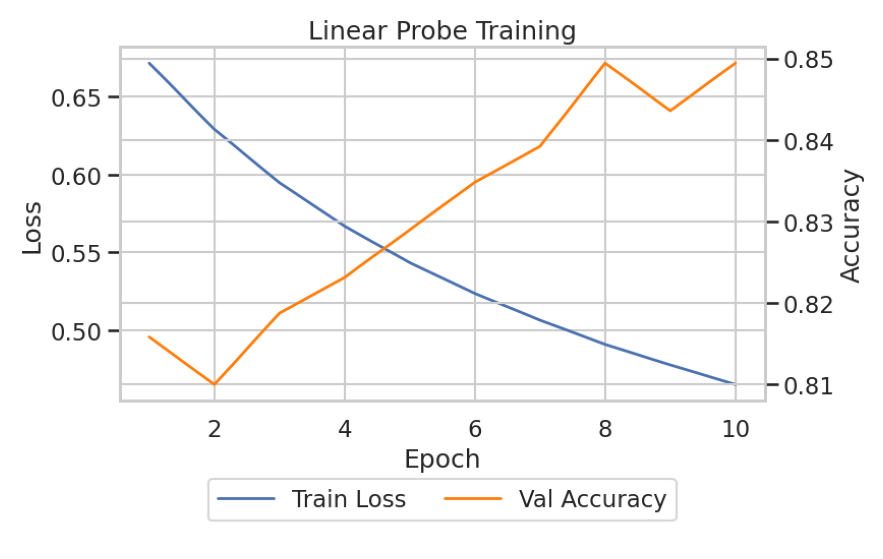

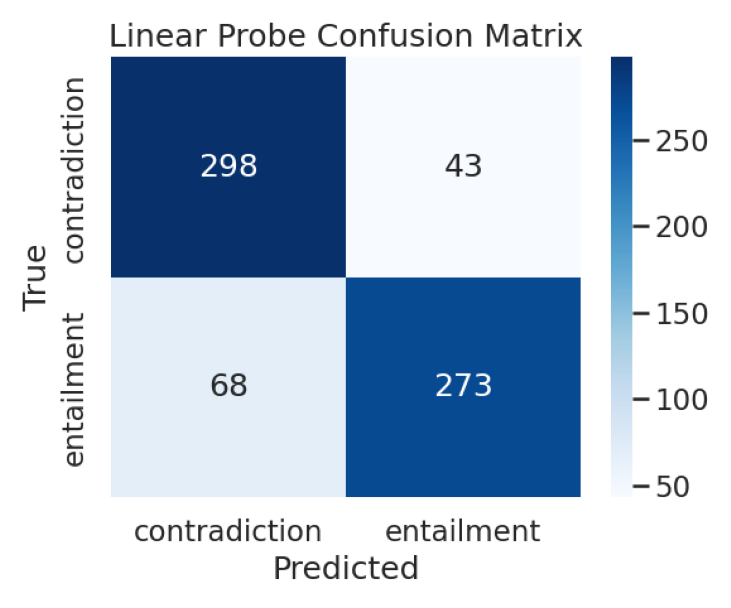

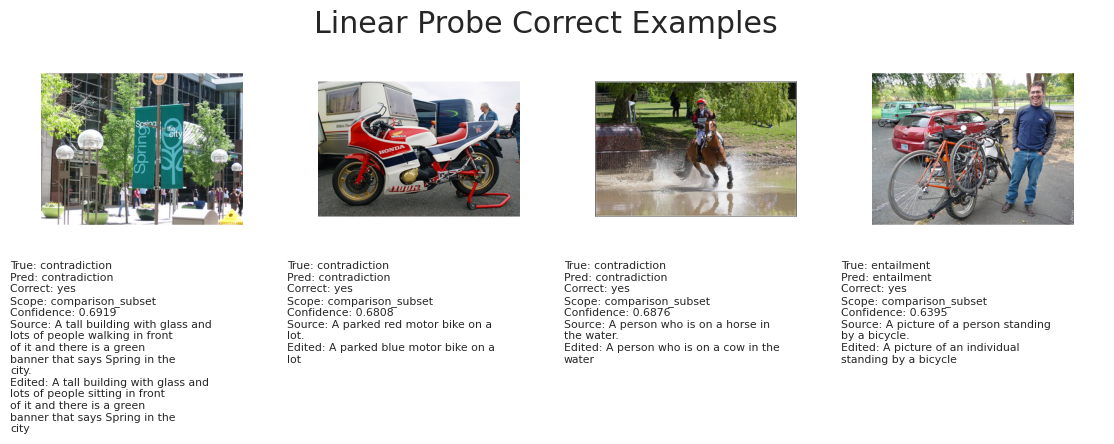

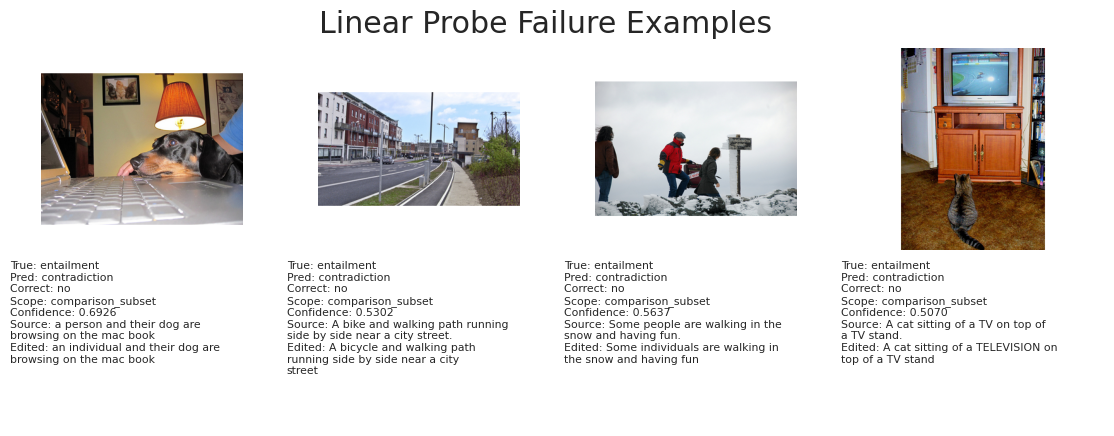

In [19]:
if RUN_LINEAR_PROBE:
    linear_metrics = linear_sweep.best_test_metrics
    linear_logits = linear_sweep.best_test_logits
    linear_labels = linear_sweep.best_test_labels
    linear_predictions = linear_logits.argmax(dim=1).numpy()
    linear_confidence = torch.softmax(linear_logits, dim=1).max(dim=1).values.numpy()

    linear_view = split_frames['test'].copy()
    linear_view['pred_label'] = [CLASS_ORDER[idx] for idx in linear_predictions]
    linear_view['confidence'] = linear_confidence
    linear_view['correct'] = linear_view['label'] == linear_view['pred_label']

    linear_train_png = resolve_figure_output(runtime.figure_root, 'linear_probe', f"linear_probe_training_{CURRENT_STAGE}.png")
    linear_conf_png = resolve_figure_output(runtime.figure_root, 'linear_probe', f"linear_probe_confusion_{CURRENT_STAGE}.png")

    save_training_curves(linear_result.history, linear_train_png, "Linear Probe Training")
    save_confusion_matrix(linear_metrics['confusion_matrix'], CLASS_ORDER, linear_conf_png, "Linear Probe Confusion Matrix")

    linear_metrics_path = runtime.metrics_root / f"linear_probe_metrics_{CURRENT_STAGE}.json"
    linear_family_path = runtime.metrics_root / f"linear_probe_per_family_{CURRENT_STAGE}.csv"
    linear_sweep_path = runtime.metrics_root / f"linear_probe_sweep_{CURRENT_STAGE}.csv"
    linear_best_trial_path = runtime.metrics_root / f"linear_probe_best_trial_{CURRENT_STAGE}.json"
    linear_predictions_path = runtime.metrics_root / f"linear_probe_predictions_{CURRENT_STAGE}.csv"
    linear_family_metrics = per_edit_family_metrics(linear_view)
    linear_full_export, linear_comparison_export, linear_predictions_export = export_model_predictions(
        linear_view,
        model_name='linear_probe',
        comparison_sample_ids=comparison_sample_ids,
        output_path=linear_predictions_path,
        stage=CURRENT_STAGE,
    )
    linear_sweep_df.to_csv(linear_sweep_path, index=False)
    linear_metrics_payload = {
        **linear_metrics,
        "best_trial": linear_sweep.best_trial_row,
        "selection_metric": config.training.selection_metric,
        "best_checkpoint": str(linear_sweep.best_checkpoint) if linear_sweep.best_checkpoint else None,
    }
    linear_metrics_path.write_text(json.dumps(linear_metrics_payload, indent=2), encoding='utf-8')
    linear_best_trial_path.write_text(json.dumps(linear_sweep.best_trial_row, indent=2), encoding='utf-8')
    linear_family_metrics.to_csv(linear_family_path, index=False)
    print("Linear probe metrics", linear_metrics)
    print(f"Saved linear probe sweep summary to {linear_sweep_path}")
    print(f"Saved linear probe per-family metrics to {linear_family_path}")
    print(f"Saved linear probe prediction export to {linear_predictions_path}")

    show_saved_figure(linear_train_png, figsize=(10, 5.5))
    show_saved_figure(linear_conf_png, figsize=(8.5, 6))
    show_prediction_examples(linear_comparison_export.query('correct'), "Linear Probe Correct Examples", n=4, seed=13)
    show_prediction_examples(linear_comparison_export.query('not correct'), "Linear Probe Failure Examples", n=4, seed=17)


## 8. Cross-Attention Fusion

This section uses frozen CLIP token states and a lightweight cross-attention head.

In [20]:
if RUN_CROSS_ATTENTION:
    cross_trials = get_stage_trials(config.training, CURRENT_STAGE, "cross_attention")
    cross_trial_table = pd.DataFrame(
        [
            {
                "trial_name": trial.name,
                "epochs": trial.epochs,
                "batch_size": trial.batch_size,
                "learning_rate": trial.learning_rate,
                "weight_decay": trial.weight_decay,
            }
            for trial in cross_trials
        ]
    )
    print("Cross-attention sweep plan")
    display(cross_trial_table)

    token_store = {}
    token_labels = {}
    for split in ['train', 'val', 'test']:
        outputs = clip_split_outputs[split]
        token_store[split] = (outputs.image_tokens, outputs.text_tokens)
        token_labels[split] = torch.tensor(
            [CLASS_ORDER.index(label) for label in outputs.labels],
            dtype=torch.long,
        )
        print(
            f"Prepared {split} token tensors: "
            f"image={tuple(token_store[split][0].shape)}, text={tuple(token_store[split][1].shape)}"
        )


Cross-attention sweep plan


,trial_name,epochs,batch_size,learning_rate,weight_decay
0,ca_f1,25,8,0.00050,0.010
1,ca_f2,30,8,0.00030,0.010
2,ca_f3,35,4,0.00010,0.010
3,ca_f4,40,8,0.00010,0.005
4,ca_f5,35,8,0.00030,0.001
5,ca_f6,30,4,0.00010,0.001
6,ca_f7,25,4,0.00005,0.005


Prepared train token tensors: image=(3186, 50, 768), text=(3186, 77, 512)
Prepared val token tensors: image=(684, 50, 768), text=(684, 77, 512)
Prepared test token tensors: image=(682, 50, 768), text=(682, 77, 512)


In [21]:
if RUN_CROSS_ATTENTION:
    cross_sweep = run_training_sweep(
        model_name="cross_attention",
        model_factory=lambda: CrossAttentionFusionClassifier(
            image_input_dim=token_store['train'][0].shape[-1],
            text_input_dim=token_store['train'][1].shape[-1],
            hidden_dim=config.model.hidden_dim,
            num_heads=config.model.num_attention_heads,
            dropout=config.model.dropout,
        ),
        train_dataset=TokenDataset(token_store['train'][0], token_store['train'][1], token_labels['train']),
        val_dataset=TokenDataset(token_store['val'][0], token_store['val'][1], token_labels['val']),
        test_dataset=TokenDataset(token_store['test'][0], token_store['test'][1], token_labels['test']),
        trials=cross_trials,
        device=runtime.device,
        num_workers=config.training.num_workers,
        selection_metric=config.training.selection_metric,
        log_root=runtime.log_root,
        checkpoint_root=runtime.checkpoint_root,
        canonical_checkpoint_path=runtime.checkpoint_root / f"cross_attention_{CURRENT_STAGE}.pt",
        amp=runtime.performance.amp_training,
        amp_precision=runtime.performance.training_amp_precision,
        early_stopping_patience=runtime.performance.early_stopping_patience,
        early_stopping_min_delta=runtime.performance.early_stopping_min_delta,
        pin_memory=runtime.device.type == 'cuda',
        persistent_workers=runtime.performance.persistent_workers,
        prefetch_factor=runtime.performance.prefetch_factor,
    )
    cross_attention = cross_sweep.best_model
    cross_result = cross_sweep.best_result
    cross_sweep_df = pd.DataFrame(cross_sweep.trial_rows)
    print("Cross-attention sweep results")
    display(cross_sweep_df)
    print(f"Best cross-attention trial: {cross_sweep.best_trial.name}")


/content/project/src/vl_contradiction/training.py:286: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  torch.cuda.amp.GradScaler(enabled=amp_enabled and amp_dtype == torch.float16)


Epoch 01/25 | train_loss=0.2878 | val_macro_f1=0.9532
Epoch 02/25 | train_loss=0.1645 | val_macro_f1=0.8522
Epoch 03/25 | train_loss=0.1237 | val_macro_f1=0.9605
Epoch 04/25 | train_loss=0.0968 | val_macro_f1=0.9561
Epoch 05/25 | train_loss=0.0886 | val_macro_f1=0.9517


/content/project/src/vl_contradiction/training.py:286: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  torch.cuda.amp.GradScaler(enabled=amp_enabled and amp_dtype == torch.float16)


Epoch 01/30 | train_loss=0.3053 | val_macro_f1=0.9076
Epoch 02/30 | train_loss=0.1609 | val_macro_f1=0.9576
Epoch 03/30 | train_loss=0.1175 | val_macro_f1=0.9473
Epoch 04/30 | train_loss=0.0994 | val_macro_f1=0.8708


/content/project/src/vl_contradiction/training.py:286: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  torch.cuda.amp.GradScaler(enabled=amp_enabled and amp_dtype == torch.float16)


...

Epoch 01/30 | train_loss=0.3345 | val_macro_f1=0.9312
Epoch 02/30 | train_loss=0.1710 | val_macro_f1=0.9385
Epoch 03/30 | train_loss=0.1279 | val_macro_f1=0.9605
Epoch 04/30 | train_loss=0.1016 | val_macro_f1=0.9073
Epoch 05/30 | train_loss=0.0882 | val_macro_f1=0.9503


/content/project/src/vl_contradiction/training.py:286: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  torch.cuda.amp.GradScaler(enabled=amp_enabled and amp_dtype == torch.float16)


Epoch 01/25 | train_loss=0.4065 | val_macro_f1=0.9149
Epoch 02/25 | train_loss=0.2093 | val_macro_f1=0.9459
Epoch 03/25 | train_loss=0.1537 | val_macro_f1=0.9444
Epoch 04/25 | train_loss=0.1280 | val_macro_f1=0.9590
Epoch 05/25 | train_loss=0.1005 | val_macro_f1=0.9207
Epoch 06/25 | train_loss=0.0896 | val_macro_f1=0.9620
Epoch 07/25 | train_loss=0.0745 | val_macro_f1=0.9532
Epoch 08/25 | train_loss=0.0688 | val_macro_f1=0.9590
Cross-attention sweep results


,trial_name,epochs,batch_size,learning_rate,weight_decay,val_macro_f1,val_accuracy,test_macro_f1,test_accuracy,checkpoint_path,log_dir
0,ca_f5,35,8,0.00030,0.001,0.963448,0.963450,0.922165,0.922287,/content/project/artifacts/checkpoints/final/c...,/content/project/artifacts/logs/final/cross_at...
1,ca_f7,25,4,0.00005,0.005,0.961985,0.961988,0.942815,0.942815,/content/project/artifacts/checkpoints/final/c...,/content/project/artifacts/logs/final/cross_at...
2,ca_f3,35,4,0.00010,0.010,0.960526,0.960526,0.933977,0.934018,/content/project/artifacts/checkpoints/final/c...,/content/project/artifacts/logs/final/cross_at...
3,ca_f1,25,8,0.00050,0.010,0.960512,0.960526,0.935404,0.935484,/content/project/artifacts/checkpoints/final/c...,/content/project/artifacts/logs/final/cross_at...
4,ca_f6,30,4,0.00010,0.001,0.960507,0.960526,0.934016,0.934018,/content/project/artifacts/checkpoints/final/c...,/content/project/artifacts/logs/final/cross_at...
5,ca_f2,30,8,0.00030,0.010,0.957602,0.957602,0.938383,0.938416,/content/project/artifacts/checkpoints/final/c...,/content/project/artifacts/logs/final/cross_at...
6,ca_f4,40,8,0.00010,0.005,0.954662,0.954678,0.942814,0.942815,/content/project/artifacts/checkpoints/final/c...,/content/project/artifacts/logs/final/cross_at...


Best cross-attention trial: ca_f5


Cross-attention metrics {'accuracy': 0.9222873900293255, 'macro_f1': 0.9221653979909344, 'precision_contradiction': 0.8913043478260869, 'precision_entailment': 0.9585987261146497, 'recall_contradiction': 0.9618768328445748, 'recall_entailment': 0.8826979472140762, 'confusion_matrix': [[328, 13], [40, 301]]}
Cross-attention calibration ECE: 0.0271
Saved cross-attention sweep summary to /content/project/artifacts/metrics/final/cross_attention_sweep_final.csv
Saved cross-attention per-family metrics to /content/project/artifacts/metrics/final/cross_attention_per_family_final.csv
Saved cross-attention prediction export to /content/project/artifacts/metrics/final/cross_attention_predictions_final.csv


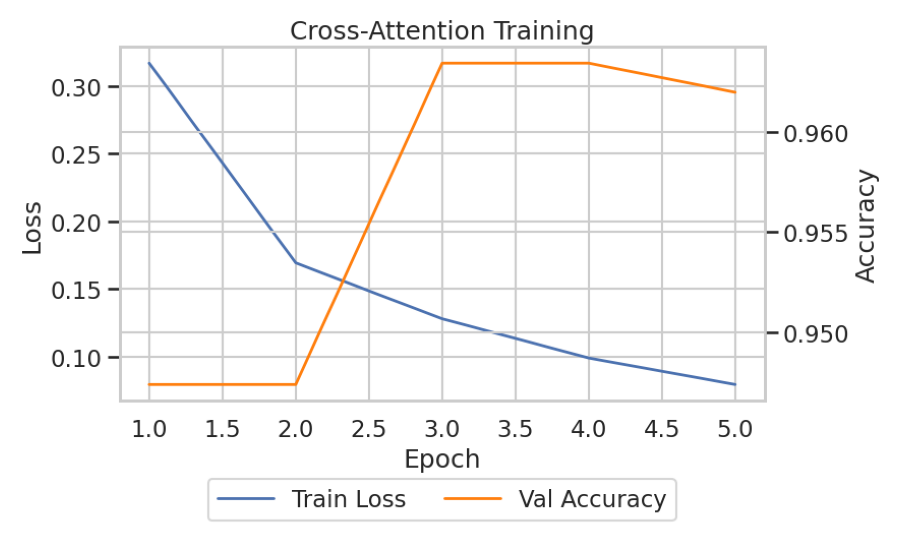

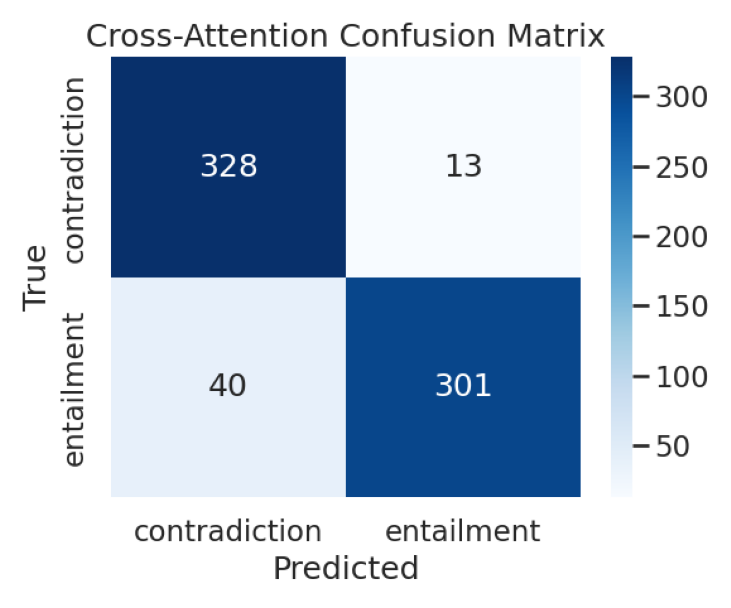

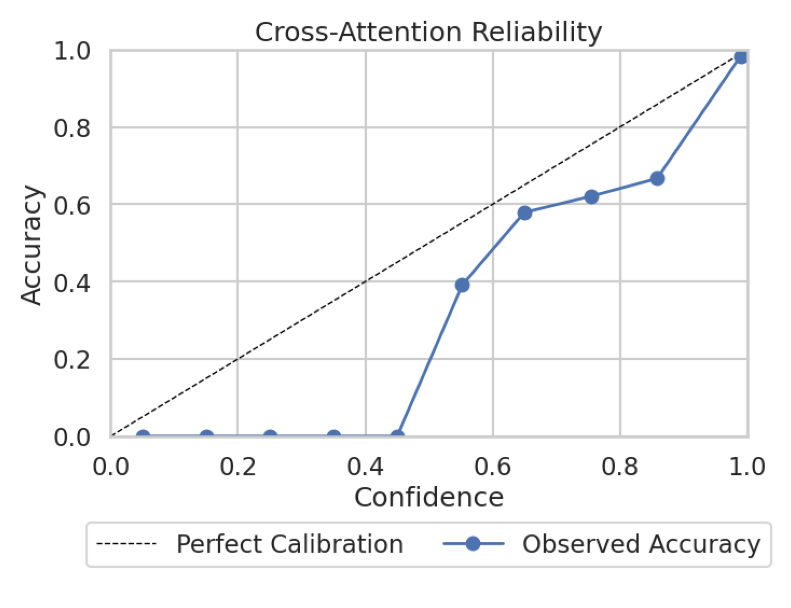

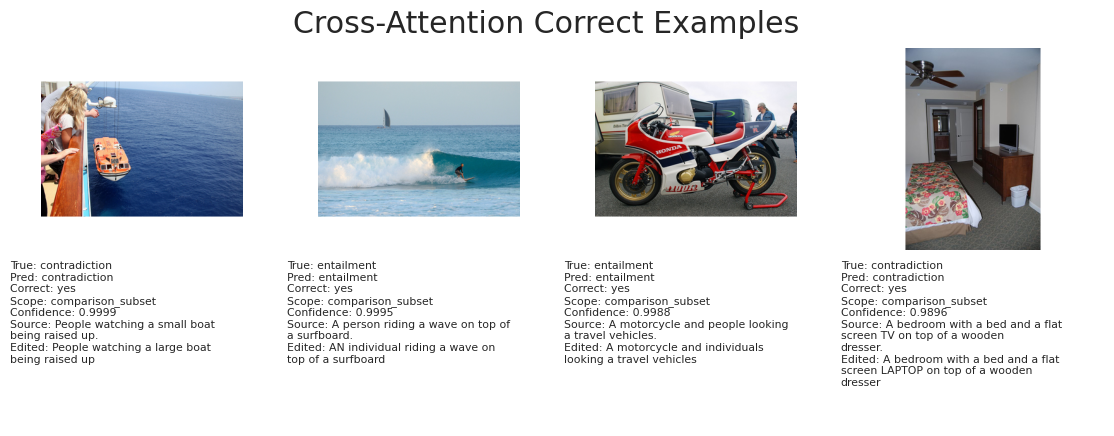

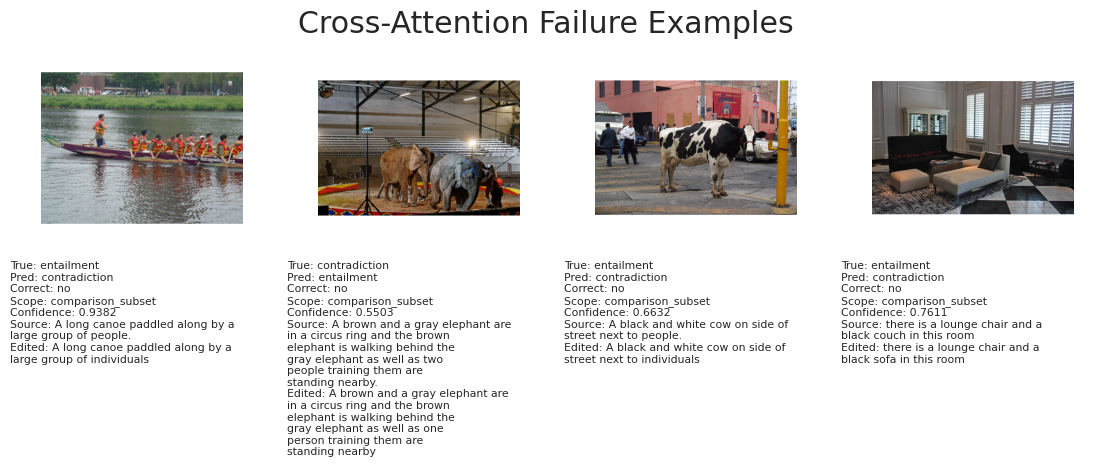

In [22]:
if RUN_CROSS_ATTENTION:
    cross_metrics = cross_sweep.best_test_metrics
    cross_logits = cross_sweep.best_test_logits
    cross_labels = cross_sweep.best_test_labels
    temperature = fit_temperature(cross_result.val_logits.to(runtime.device), cross_result.val_labels.to(runtime.device))
    calibrated_probs = torch.softmax(cross_logits / temperature, dim=1).cpu().numpy()
    calibration = expected_calibration_error(calibrated_probs, cross_labels.numpy())
    cross_predictions = cross_logits.argmax(dim=1).numpy()
    cross_confidence = torch.softmax(cross_logits, dim=1).max(dim=1).values.numpy()

    cross_view = split_frames['test'].copy()
    cross_view['pred_label'] = [CLASS_ORDER[idx] for idx in cross_predictions]
    cross_view['confidence'] = cross_confidence
    cross_view['correct'] = cross_view['label'] == cross_view['pred_label']

    cross_train_png = resolve_figure_output(runtime.figure_root, 'cross_attention', f"cross_attention_training_{CURRENT_STAGE}.png")
    cross_conf_png = resolve_figure_output(runtime.figure_root, 'cross_attention', f"cross_attention_confusion_{CURRENT_STAGE}.png")
    cross_cal_png = resolve_figure_output(runtime.figure_root, 'cross_attention', f"cross_attention_calibration_{CURRENT_STAGE}.png")

    save_training_curves(cross_result.history, cross_train_png, "Cross-Attention Training")
    save_confusion_matrix(cross_metrics['confusion_matrix'], CLASS_ORDER, cross_conf_png, "Cross-Attention Confusion Matrix")
    save_reliability_diagram(calibration.bin_centers, calibration.bin_accuracy, calibration.bin_confidence, cross_cal_png, "Cross-Attention Reliability")

    cross_metrics_path = runtime.metrics_root / f"cross_attention_metrics_{CURRENT_STAGE}.json"
    cross_family_path = runtime.metrics_root / f"cross_attention_per_family_{CURRENT_STAGE}.csv"
    cross_sweep_path = runtime.metrics_root / f"cross_attention_sweep_{CURRENT_STAGE}.csv"
    cross_best_trial_path = runtime.metrics_root / f"cross_attention_best_trial_{CURRENT_STAGE}.json"
    cross_predictions_path = runtime.metrics_root / f"cross_attention_predictions_{CURRENT_STAGE}.csv"
    cross_family_metrics = per_edit_family_metrics(cross_view)
    cross_full_export, cross_comparison_export, cross_predictions_export = export_model_predictions(
        cross_view,
        model_name='cross_attention',
        comparison_sample_ids=comparison_sample_ids,
        output_path=cross_predictions_path,
        stage=CURRENT_STAGE,
    )
    cross_sweep_df.to_csv(cross_sweep_path, index=False)
    cross_metrics_payload = {
        **cross_metrics,
        'temperature': float(temperature),
        'ece': calibration.ece,
        'best_trial': cross_sweep.best_trial_row,
        'selection_metric': config.training.selection_metric,
        'best_checkpoint': str(cross_sweep.best_checkpoint) if cross_sweep.best_checkpoint else None,
    }
    cross_metrics_path.write_text(json.dumps(cross_metrics_payload, indent=2), encoding='utf-8')
    cross_best_trial_path.write_text(json.dumps(cross_sweep.best_trial_row, indent=2), encoding='utf-8')
    cross_family_metrics.to_csv(cross_family_path, index=False)
    print("Cross-attention metrics", cross_metrics)
    print(f"Cross-attention calibration ECE: {calibration.ece:.4f}")
    print(f"Saved cross-attention sweep summary to {cross_sweep_path}")
    print(f"Saved cross-attention per-family metrics to {cross_family_path}")
    print(f"Saved cross-attention prediction export to {cross_predictions_path}")

    show_saved_figure(cross_train_png, figsize=(10, 5.5))
    show_saved_figure(cross_conf_png, figsize=(8.5, 6))
    show_saved_figure(cross_cal_png, figsize=(8.5, 6))
    show_prediction_examples(cross_comparison_export.query('correct'), "Cross-Attention Correct Examples", n=4, seed=19)
    show_prediction_examples(cross_comparison_export.query('not correct'), "Cross-Attention Failure Examples", n=4, seed=23)


## 9. Qwen2.5-VL Zero-Shot Reference

This section runs on the saved comparison subset. When the requested subset size is at least the test split size, Qwen evaluates the full test split; otherwise it uses the fixed stratified subset. Raw outputs are cached so reruns stay cheap.

In [23]:
comparison_subset[['label', 'edit_family']].value_counts().head(12)


label          edit_family            
entailment     entailment_synonym         341
contradiction  contradiction_count        118
               contradiction_action        98
               contradiction_attribute     64
               contradiction_object        61
Name: count, dtype: int64

In [ ]:
if RUN_QWEN:
    resolved_qwen_batch = QWEN_BATCH_SIZE_OVERRIDE or runtime.performance.qwen_batch_size or 1
    print(f"[qwen] load model batch={resolved_qwen_batch}", flush=True)
    qwen_bundle = load_qwen_bundle(
        config.model.qwen_name,
        use_4bit=config.model.use_qwen_4bit,
        batch_size=QWEN_BATCH_SIZE_OVERRIDE,
        runtime=runtime,
        performance=runtime.performance,
    )
    print(f"[qwen] loaded precision={qwen_bundle.policy.precision} batch={qwen_bundle.policy.batch_size or resolved_qwen_batch}", flush=True)
    print(f"[qwen] run rows={len(comparison_subset)}", flush=True)
    qwen_outputs = run_qwen_inference(
        comparison_subset,
        qwen_bundle,
        output_dir=runtime.qwen_root,
        max_new_tokens=config.model.max_qwen_tokens,
        batch_size=QWEN_BATCH_SIZE_OVERRIDE,
        runtime=runtime,
        performance=runtime.performance,
    )
    qwen_outputs = comparison_subset[
        ['sample_id', 'file_path', 'source_caption', 'edited_caption', 'edit_family', 'label']
    ].merge(
        qwen_outputs.drop(columns=['label']),
        on='sample_id',
        how='left',
    )
    qwen_outputs['correct'] = qwen_outputs['label'] == qwen_outputs['pred_label']
    qwen_predictions_path = runtime.metrics_root / f"qwen_predictions_{CURRENT_STAGE}.csv"
    qwen_comparison_export = standardize_prediction_frame(
        qwen_outputs,
        model='qwen',
        stage=CURRENT_STAGE,
        eval_scope='comparison_subset',
    )
    qwen_comparison_export.to_csv(qwen_predictions_path, index=False)
    qwen_eval = qwen_outputs.loc[qwen_outputs['pred_label'].isin(CLASS_ORDER)].copy()
    qwen_eval['y_true'] = qwen_eval['label'].map(LABEL_TO_INDEX)
    qwen_eval['y_pred'] = qwen_eval['pred_label'].map(LABEL_TO_INDEX)
    qwen_metrics = compute_classification_metrics(qwen_eval['y_true'].to_numpy(), qwen_eval['y_pred'].to_numpy())
    qwen_metrics_path = runtime.metrics_root / f"qwen_metrics_{CURRENT_STAGE}.json"
    qwen_family_path = runtime.metrics_root / f"qwen_per_family_{CURRENT_STAGE}.csv"
    qwen_family_metrics = per_edit_family_metrics(qwen_eval)
    qwen_metrics_payload = {
        **qwen_metrics,
        'sample_count': int(len(qwen_eval)),
        'comparison_subset_size': int(len(comparison_subset)),
    }
    qwen_metrics_path.write_text(json.dumps(qwen_metrics_payload, indent=2), encoding='utf-8')
    qwen_family_metrics.to_csv(qwen_family_path, index=False)
    print("Qwen metrics", qwen_metrics)
    print(f"Saved Qwen per-family metrics to {qwen_family_path}")
    print(f"Saved Qwen prediction export to {qwen_predictions_path}")


[qwen] load model batch=28


preprocessor_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

chat_template.json: 0.00B [00:00, ?B/s]

The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/216 [00:00<?, ?B/s]

[qwen] loaded precision=fp16 batch=28
[qwen] run rows=682
[qwen] start total=682 cached=0 run=682 batch=28 precision=fp16
[qwen] call=1 rows=1-28/682 batch=28


The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


[qwen] call=2 rows=29-56/682 batch=28


## 10. Model Comparison And Qualitative Exports

Use this section after model runs to save standardized prediction exports, cross-model comparison tables and figures, and matched per-model qualitative panels.


In [ ]:
family_counts = benchmark_frame.groupby(['edit_family', 'label']).size().reset_index(name='count')
family_pivot = family_counts.pivot(index='edit_family', columns='label', values='count').fillna(0).sort_index()
family_pivot = family_pivot.reindex(columns=[label for label in CLASS_ORDER if label in family_pivot.columns], fill_value=0)
family_colors = {
    'contradiction': '#c44e52',
    'entailment': '#4c72b0',
}

family_png = resolve_figure_output(runtime.figure_root, 'benchmark', f"benchmark_family_counts_{CURRENT_STAGE}.png")

fig, ax = plt.subplots(figsize=(11.5, 5.5))
family_pivot.plot(
    kind='bar',
    ax=ax,
    color=[family_colors[label] for label in family_pivot.columns],
    width=0.8,
)
ax.set_title('Benchmark Distribution by Edit Family')
ax.set_xlabel('Edit Family')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=35)
for tick in ax.get_xticklabels():
    tick.set_ha('right')
ax.legend(title='Label', loc='upper left', bbox_to_anchor=(1.02, 1.0), borderaxespad=0.0, frameon=True)
fig.subplots_adjust(left=0.08, right=0.80, bottom=0.24, top=0.90)
fig.savefig(family_png, bbox_inches='tight')
plt.close(fig)

print(family_pivot)
show_saved_figure(family_png, figsize=(12, 5.5))


In [ ]:
comparison_frames = {}
model_display_names = {
    'raw_clip': 'Raw CLIP',
    'linear_probe': 'Linear Probe',
    'cross_attention': 'Cross-Attention',
    'qwen': 'Qwen2.5-VL',
}

if RUN_RAW_CLIP:
    comparison_frames['raw_clip'] = raw_clip_comparison_export.copy()
if RUN_LINEAR_PROBE:
    comparison_frames['linear_probe'] = linear_comparison_export.copy()
if RUN_CROSS_ATTENTION:
    comparison_frames['cross_attention'] = cross_comparison_export.copy()
if RUN_QWEN:
    comparison_frames['qwen'] = qwen_comparison_export.loc[qwen_comparison_export['pred_label'].isin(CLASS_ORDER)].copy()

if not comparison_frames:
    print('No model comparison frames are available.')
else:
    common_sample_ids = sorted(set.intersection(*(set(frame['sample_id']) for frame in comparison_frames.values())))
    comparison_frames = {
        model_name: slice_prediction_frame(frame, common_sample_ids)
        for model_name, frame in comparison_frames.items()
    }
    comparison_summary_path = runtime.metrics_root / f"model_comparison_summary_{CURRENT_STAGE}.csv"
    comparison_family_path = runtime.metrics_root / f"model_comparison_per_family_{CURRENT_STAGE}.csv"
    qualitative_manifest_path = runtime.metrics_root / f"qualitative_selection_{CURRENT_STAGE}.csv"
    comparison_summary, comparison_family = save_comparison_tables(
        comparison_frames,
        comparison_summary_path,
        comparison_family_path,
    )

    overall_png = resolve_figure_output(runtime.figure_root, 'comparison', f"model_comparison_overall_{CURRENT_STAGE}.png")
    family_png = resolve_figure_output(runtime.figure_root, 'comparison', f"model_comparison_per_family_accuracy_{CURRENT_STAGE}.png")

    save_grouped_comparison_chart(comparison_summary, overall_png, 'Overall Model Comparison')
    save_per_family_accuracy_heatmap(comparison_family, family_png, 'Per-Family Accuracy by Model')

    qualitative_selection = select_matched_qualitative_samples(
        comparison_frames,
        correct_count=8,
        failure_count=8,
        seed=config.runtime.seed,
    )
    qualitative_selection.manifest.to_csv(qualitative_manifest_path, index=False)

    for model_name, model_frame in comparison_frames.items():
        display_name = model_display_names[model_name]
        correct_frame = slice_prediction_frame(model_frame, qualitative_selection.correct_sample_ids)
        failure_frame = slice_prediction_frame(model_frame, qualitative_selection.failure_sample_ids)
        correct_png = resolve_figure_output(runtime.figure_root, 'qualitative', model_name, f"{model_name}_qualitative_correct_{CURRENT_STAGE}.png")
        failure_png = resolve_figure_output(runtime.figure_root, 'qualitative', model_name, f"{model_name}_qualitative_failure_{CURRENT_STAGE}.png")
        save_qualitative_panel(correct_frame, correct_png, f"{display_name} Correct Examples", max_rows=len(correct_frame))
        save_qualitative_panel(failure_frame, failure_png, f"{display_name} Failure Examples", max_rows=len(failure_frame))

    print(f"Saved comparison summary to {comparison_summary_path}")
    print(f"Saved comparison per-family table to {comparison_family_path}")
    print(f"Saved qualitative selection manifest to {qualitative_manifest_path}")
    display(comparison_summary)
    display(comparison_family.head(12))
    show_saved_figure(overall_png, figsize=(10, 5.8))
    show_saved_figure(family_png, figsize=(11, 6.5))


## 11. Summary of Generated Artifacts

This section gives a quick view of the benchmark, metrics, checkpoints, and figure outputs produced by the notebook.

In [ ]:
artifact_roots = [
    runtime.benchmark_root,
    runtime.metrics_root,
    runtime.figure_root,
    runtime.checkpoint_root,
    runtime.qwen_root,
]
for root in artifact_roots:
    print(f"\nArtifacts under {root}")
    for path in sorted(root.glob('*'))[:10]:
        print(f"  - {path.name}")

## 12. Final Run Readiness

This cell checks benchmark coverage and required Qwen artifacts for the configured final run.


In [ ]:
qwen_metrics_path = runtime.metrics_root / f"qwen_metrics_{CURRENT_STAGE}.json"
qwen_cache_dir = runtime.qwen_root
qwen_cache_files = sorted(qwen_cache_dir.glob("*.json")) if qwen_cache_dir.exists() else []

readiness_reasons = []
if not coverage_shortfalls.empty:
    failing = ", ".join(coverage_shortfalls["edit_family"].tolist())
    readiness_reasons.append(
        f"benchmark coverage below the minimum family count ({coverage_minimum}) for: {failing}"
    )

if config.audit.require_qwen_for_readiness:
    if not RUN_QWEN:
        readiness_reasons.append("RUN_QWEN is False, so the required Qwen baseline was not executed")
    if not qwen_metrics_path.exists():
        readiness_reasons.append(f"missing Qwen metrics artifact: {qwen_metrics_path.name}")
    if len(qwen_cache_files) < len(comparison_subset):
        readiness_reasons.append(
            f"Qwen cache incomplete: found {len(qwen_cache_files)} outputs for {len(comparison_subset)} subset rows"
        )

ready_to_scale = not readiness_reasons
readiness_report = {
    "ready_to_scale": ready_to_scale,
    "benchmark_rows": int(len(benchmark_frame)),
    "benchmark_families": int(family_manifest.shape[0]),
    "comparison_subset_rows": int(len(comparison_subset)),
    "qwen_outputs": int(len(qwen_cache_files)),
    "reasons": readiness_reasons,
}
print(json.dumps(readiness_report, indent=2))
if ready_to_scale:
    print("Final run readiness: PASS")
else:
    print("Final run readiness: FAIL")


In [ ]:
# Run this only as the final cell in Colab to release the attached GPU runtime.
try:
    from google.colab import runtime as colab_runtime
except ImportError:
    print("Not running in Google Colab; leaving the current Python session active.")
else:
    print("Disconnecting and deleting the Colab runtime to stop GPU billing...")
    colab_runtime.unassign()
